# Energy Consumption Forecasting Pipeline

This notebook builds an end-to-end pipeline for:

- Energy consumption forecasting
- Anomaly detection
- Cost optimization (CURRENTLY NOT IN USE)
- LLM summarization with Gemini (CURRENTLY NOT IN USE)

It is designed for records shaped like the sample JSON document provided by the user.

## Workflow

1. Load raw energy records
2. Convert timestamps and build time-based features
3. Create lag and rolling window features
4. Train a multivariate forecasting model
5. Score anomalies with forecast residuals and Isolation Forest
6. Estimate cost optimization opportunities
7. Generate a business summary using Gemini

In [ ]:
import json
import os
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBRegressor

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.multioutput import MultiOutputRegressor  # predicting multiple numerical values simultaneously (multi-step time series forecasting)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.impute import SimpleImputer # handle missing data in datasets by replacing missing values with a specified strategy
from sklearn.pipeline import Pipeline  # chain together multiple steps in a machine learning workflow
from sklearn.compose import ColumnTransformer

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)

In [46]:
MODEL_DIR = "E:\Projects\IOT-AI-Implementation\models\M6"

## Data Loading

In [ ]:
from pymongo import MongoClient, DESCENDING
client = MongoClient("string
db = client["IOTDeviceMonitor"]
collection = db["FUTU00_DataMonitor"]  

In [ ]:
query = {"EnergymeterId": "FUTU0000000004000002"}
cursor = collection.find(query).sort("_id", DESCENDING)
data = list(cursor)
maindf = pd.DataFrame(data)

In [47]:
df = maindf.copy(deep=True)

In [48]:
df.shape

(980984, 6)

In [49]:
df.columns

Index(['_id', 'UID', 'RTC', 'A1', 'EnergymeterId', 'timestamp'], dtype='str')

## Feature Engineering

In [50]:
# TARGET_COLS = ['total_kwh'] # Energy
TARGET_COLS = ['target_diff']  

In [51]:
# Convert types
df['A1'] = pd.to_numeric(df['A1'], errors='coerce')
df['RTC'] = pd.to_datetime(df['RTC'])

In [52]:
# Rename for consistency
df = df.rename(columns={
    'A1': 'total_kwh',
    'RTC': 'rtc_timestamp',
    'EnergymeterId': 'meter_id'
})

# Sort (VERY IMPORTANT for time series)
df = df.sort_values(['meter_id', 'rtc_timestamp'])

# Mark invalid rows as missing 
df.loc[df['total_kwh'] == 0, 'total_kwh'] = np.nan
df = df.dropna()

In [53]:
df = df.set_index('rtc_timestamp')

numeric_cols = df.select_dtypes(include=[np.number]).columns

df = (df.groupby('meter_id')[numeric_cols].resample('1h').mean().reset_index())

In [54]:
df.shape

(12989, 3)

In [55]:
df.columns

Index(['meter_id', 'rtc_timestamp', 'total_kwh'], dtype='str')

In [56]:
df = df.sort_values(['meter_id', 'rtc_timestamp'])

In [ ]:
# add time features
def add_time_features(df: pd.DataFrame):
    out = df.copy()
    out['hour_of_day'] = out['rtc_timestamp'].dt.hour
    out['day_of_week'] = out['rtc_timestamp'].dt.dayofweek
    out['diff_2'] = out['total_kwh'].diff(2)
    out['rolling_max_6'] = out.groupby('meter_id')['total_kwh'].rolling(6).max().reset_index(level=0, drop=True)
    out['rolling_min_6'] = out.groupby('meter_id')['total_kwh'].rolling(6).min().reset_index(level=0, drop=True)
    out['rolling_range_6'] = out['rolling_max_6'] - out['rolling_min_6']
    return out

# captures periodicity
def add_time_signals(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour_sin'] = np.sin(2 * np.pi * out['hour_of_day'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour_of_day'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['day_of_week'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['day_of_week'] / 7)
    return out

# yesterday/hour ago usage
def add_lag_features(df: pd.DataFrame, cols: List[str], lags: List[int] = [1, 2, 3, 6, 12, 24]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        for lag in lags:
            out[f'{col}_lag_{lag}'] = out.groupby('meter_id')[col].shift(lag)
    return out

# smoothing trends
def add_rolling_features(df: pd.DataFrame, cols: List[str], windows: List[int] = [3, 6, 24]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        for window in windows:
            rolled = out.groupby('meter_id')[col].rolling(window=window, min_periods=1)
            out[f'{col}_roll_std_{window}'] = rolled.std().reset_index(level=0, drop=True)
    return out

In [59]:
feature_df = add_time_features(df)
feature_df = add_time_signals(df)
feature_df = add_lag_features(feature_df, ['total_kwh'])
feature_df['target_diff'] = feature_df['total_kwh'] - feature_df['total_kwh_lag_1']
feature_df = feature_df[feature_df['target_diff'].abs() > 1]
feature_df = add_rolling_features(feature_df, ['total_kwh'])
feature_df = feature_df.dropna().reset_index(drop=True)
feature_df.head()

,meter_id,rtc_timestamp,total_kwh,hour_of_day,day_of_week,diff_2,rolling_max_6,rolling_min_6,rolling_range_6,hour_sin,hour_cos,dow_sin,dow_cos,total_kwh_lag_1,total_kwh_lag_2,total_kwh_lag_3,total_kwh_lag_6,total_kwh_lag_12,total_kwh_lag_24,target_diff,total_kwh_roll_std_3,total_kwh_roll_std_6,total_kwh_roll_std_24
0,FUTU0000000004000002,2024-10-17 04:00:00,80518.441618,4,3,4.131618,80518.441618,80437.611129,80.830489,0.866025,5.000000e-01,0.433884,-0.900969,80514.310000,80514.310000,80507.869867,80412.541622,80223.475600,79909.906296,4.131618,5.327718,44.302810,193.821698
1,FUTU0000000004000002,2024-10-17 05:00:00,80530.727361,5,3,16.417361,80530.727361,80470.285522,60.441839,0.965926,2.588190e-01,0.433884,-0.900969,80518.441618,80514.310000,80514.310000,80437.611129,80259.587222,79932.895857,12.285743,8.539511,35.368078,199.091950
2,FUTU0000000004000002,2024-10-17 06:00:00,80532.190000,6,3,13.748382,80532.190000,80507.869867,24.320133,1.000000,6.123234e-17,0.433884,-0.900969,80530.727361,80518.441618,80514.310000,80470.285522,80296.211429,79960.611061,1.462639,7.550903,22.635289,195.801399
3,FUTU0000000004000002,2024-10-17 08:00:00,80534.135556,8,3,1.945556,80534.135556,80514.310000,19.825556,0.866025,-5.000000e-01,0.433884,-0.900969,80532.190000,80532.190000,80530.727361,80514.310000,80359.513175,80008.227973,1.945556,1.709790,10.893732,191.352322
4,FUTU0000000004000002,2024-10-17 09:00:00,80558.084265,9,3,25.894265,80558.084265,80518.441618,39.642647,0.707107,-7.071068e-01,0.433884,-0.900969,80534.135556,80532.190000,80532.190000,80514.310000,80385.507463,80040.995915,23.948709,14.421274,15.365897,186.311451


In [60]:
feature_df.columns

Index(['meter_id', 'rtc_timestamp', 'total_kwh', 'hour_of_day', 'day_of_week',
       'diff_2', 'rolling_max_6', 'rolling_min_6', 'rolling_range_6',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'total_kwh_lag_1',
       'total_kwh_lag_2', 'total_kwh_lag_3', 'total_kwh_lag_6',
       'total_kwh_lag_12', 'total_kwh_lag_24', 'target_diff',
       'total_kwh_roll_std_3', 'total_kwh_roll_std_6',
       'total_kwh_roll_std_24'],
      dtype='str')

## Train / Test Split

In [61]:
# Chronological split (important for time-series)
split_idx = int(len(feature_df) * 0.8)
train_df = feature_df.iloc[:split_idx].copy()
test_df = feature_df.iloc[split_idx:].copy()

In [62]:
train_df.columns, test_df.columns

(Index(['meter_id', 'rtc_timestamp', 'total_kwh', 'hour_of_day', 'day_of_week',
        'diff_2', 'rolling_max_6', 'rolling_min_6', 'rolling_range_6',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'total_kwh_lag_1',
        'total_kwh_lag_2', 'total_kwh_lag_3', 'total_kwh_lag_6',
        'total_kwh_lag_12', 'total_kwh_lag_24', 'target_diff',
        'total_kwh_roll_std_3', 'total_kwh_roll_std_6',
        'total_kwh_roll_std_24'],
       dtype='str'),
 Index(['meter_id', 'rtc_timestamp', 'total_kwh', 'hour_of_day', 'day_of_week',
        'diff_2', 'rolling_max_6', 'rolling_min_6', 'rolling_range_6',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'total_kwh_lag_1',
        'total_kwh_lag_2', 'total_kwh_lag_3', 'total_kwh_lag_6',
        'total_kwh_lag_12', 'total_kwh_lag_24', 'target_diff',
        'total_kwh_roll_std_3', 'total_kwh_roll_std_6',
        'total_kwh_roll_std_24'],
       dtype='str'))

In [63]:
excluded = {
    'rtc_timestamp',
    '_id',
    'meter_id',
    'UID',
    'timestamp',
    # raw target & leakage
    'total_kwh',
    'ratio_1',
    'trend_6',
    # optional drops
    'hour_of_day',
    'day_of_week',
    # optional (reduce redundancy)
    'total_kwh_roll_mean_3',
    'total_kwh_roll_mean_6',
    'total_kwh_roll_mean_24'
}

model_features = [
    c for c in feature_df.columns
    if c not in excluded.union(TARGET_COLS)
]

X_train = train_df[model_features]
y_train = train_df[TARGET_COLS]
X_test = test_df[model_features]
y_test = test_df[TARGET_COLS]

len(model_features), X_train.shape, y_train.shape

(17, (8076, 17), (8076, 1))

In [64]:
print(X_train.nunique().sort_values())

dow_sin                     7
dow_cos                     7
hour_sin                   21
hour_cos                   22
total_kwh_lag_24         7232
total_kwh_lag_12         7519
total_kwh_lag_6          7786
rolling_min_6            7833
total_kwh_lag_3          7937
total_kwh_lag_2          8009
rolling_range_6          8076
diff_2                   8076
rolling_max_6            8076
total_kwh_lag_1          8076
total_kwh_roll_std_3     8076
total_kwh_roll_std_6     8076
total_kwh_roll_std_24    8076
dtype: int64


In [65]:
print(y_train.describe())

       target_diff
count  8076.000000
mean     24.974420
std       8.079152
min       1.000145
25%      20.332684
50%      24.147060
75%      30.168424
max      63.685547


## Forecasting Model

In [66]:
# explicitly define which columns go into the model
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_features

['diff_2',
 'rolling_max_6',
 'rolling_min_6',
 'rolling_range_6',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'total_kwh_lag_1',
 'total_kwh_lag_2',
 'total_kwh_lag_3',
 'total_kwh_lag_6',
 'total_kwh_lag_12',
 'total_kwh_lag_24',
 'total_kwh_roll_std_3',
 'total_kwh_roll_std_6',
 'total_kwh_roll_std_24']

In [67]:
# preprocess data so that only numeric features are used
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_features)
    ],
    remainder='drop' # Drops unused columns
)
# Random Forest Regressor
# forecast_model = Pipeline(
#     steps=[
#         ('preprocessor', preprocessor),
#         ('model', MultiOutputRegressor(RandomForestRegressor(
#             n_estimators=300,
#             max_depth=20,
#             min_samples_leaf=5,
#             random_state=42,
#             n_jobs=-1
#         )))
#     ]
# )

# XGBoost Regressor
forecast_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            n_estimators=800,
            max_depth=8,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9
        ))
    ]
)

forecast_model.fit(X_train, y_train.values.ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

### Save the Model and Features

In [68]:
# Save the model and load the model later 
joblib.dump(forecast_model, f"{MODEL_DIR}\energy_forecast_model.pkl")

['E:\\Projects\\IOT-AI-Implementation\\models\\M6\\energy_forecast_model.pkl']

In [69]:
# Save metadata
metadata = {
    "features": numeric_features,
    "target": TARGET_COLS,
    "model_type": "RandomForest"
}

joblib.dump(metadata, f"{MODEL_DIR}\model_metadata.pkl")

['E:\\Projects\\IOT-AI-Implementation\\models\\M6\\model_metadata.pkl']

In [70]:
# Save feature schema, Prevents mismatch during inference
joblib.dump(numeric_features, f"{MODEL_DIR}\model_features.pkl")

['E:\\Projects\\IOT-AI-Implementation\\models\\M6\\model_features.pkl']

### Make predictions on test data

In [ ]:
# pred_log = forecast_model.predict(X_test)
# delta_pred = np.expm1(pred_log)
# pred = X_test['total_kwh_lag_1'].values + delta_pred  # kWh + kWh diff
# pred = pd.DataFrame(pred, columns=TARGET_COLS, index=X_test.index)
# pred.head()

In [71]:
delta_pred = forecast_model.predict(X_test)
pred = X_test['total_kwh_lag_1'].values + delta_pred
pred = pd.DataFrame(pred, columns=['total_kwh'], index=X_test.index)

In [72]:
pred.head()

,total_kwh
8076,295827.233654
8077,295858.697889
8078,295891.333316
8079,295922.325435
8080,295954.793348


In [73]:
print(delta_pred[:5])

[32.062225 32.00803  32.238243 31.402102 32.56244 ]


In [74]:
print((pred['total_kwh'] - X_test['total_kwh_lag_1']).head())

8076    32.062225
8077    32.008030
8078    32.238243
8079    31.402102
8080    32.562439
dtype: float64


In [76]:
pred.std()

total_kwh    14577.953567
dtype: float64

In [77]:
def regression_metrics(actual: pd.DataFrame, predicted: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in actual.columns:
        mae = mean_absolute_error(actual[col], predicted[col])
        rmse = root_mean_squared_error(actual[col], predicted[col])
        mape = np.mean(np.abs((actual[col] - predicted[col]) / np.clip(actual[col], 1e-6, None))) * 100
        rows.append({'target': col, 'MAE': mae, 'RMSE': rmse, 'MAPE_pct': mape})
    return pd.DataFrame(rows).sort_values('RMSE')

y_test_actual = test_df['total_kwh'].loc[X_test.index]
metrics_df = regression_metrics(y_test_actual.to_frame(), pred)
metrics_df

,target,MAE,RMSE,MAPE_pct
0,total_kwh,1.791207,2.617724,0.000557


### Plot actual vs predicted energy

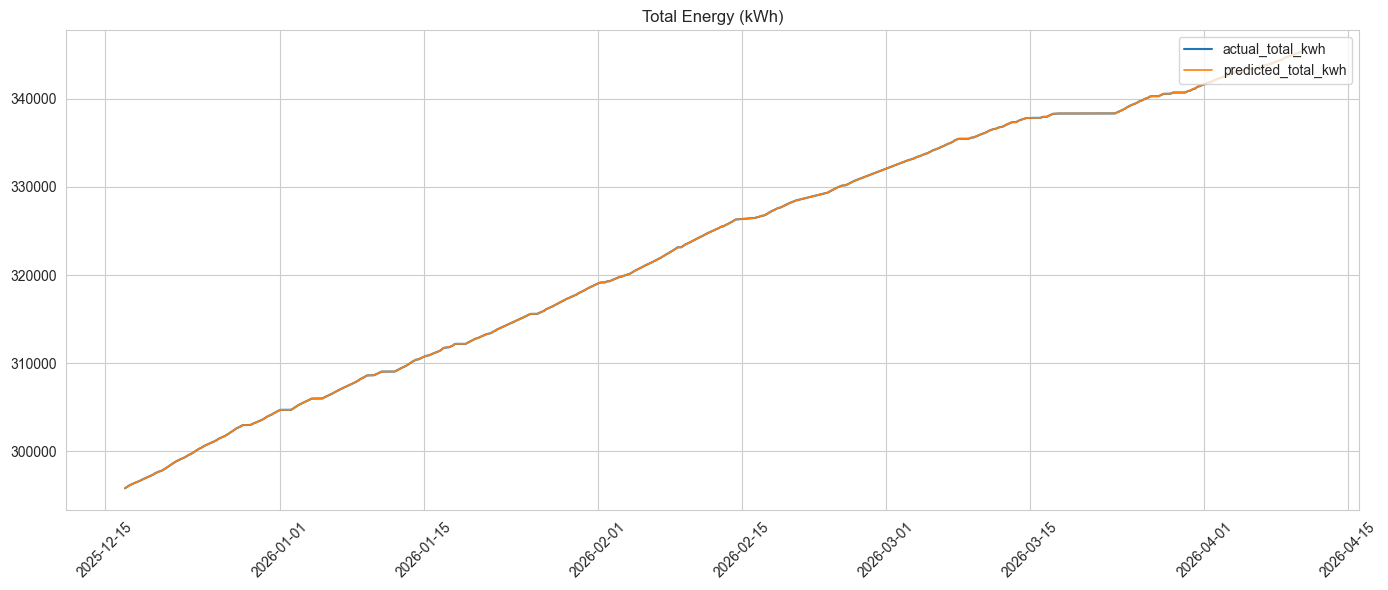

In [78]:
plot_cols = ['total_kwh']

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 6), sharex=True)

if len(plot_cols) == 1:
    axes = [axes]

x_axis = test_df.loc[X_test.index, 'rtc_timestamp']

# Actual values
y_test_actual = test_df.loc[X_test.index, 'total_kwh']

for ax, col in zip(axes, plot_cols):
    ax.plot(x_axis, y_test_actual, label='actual_total_kwh', linewidth=1.5)
    ax.plot(x_axis, pred['total_kwh'], label='predicted_total_kwh', linewidth=1.2)
    ax.set_title('Total Energy (kWh)')
    ax.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plot delta

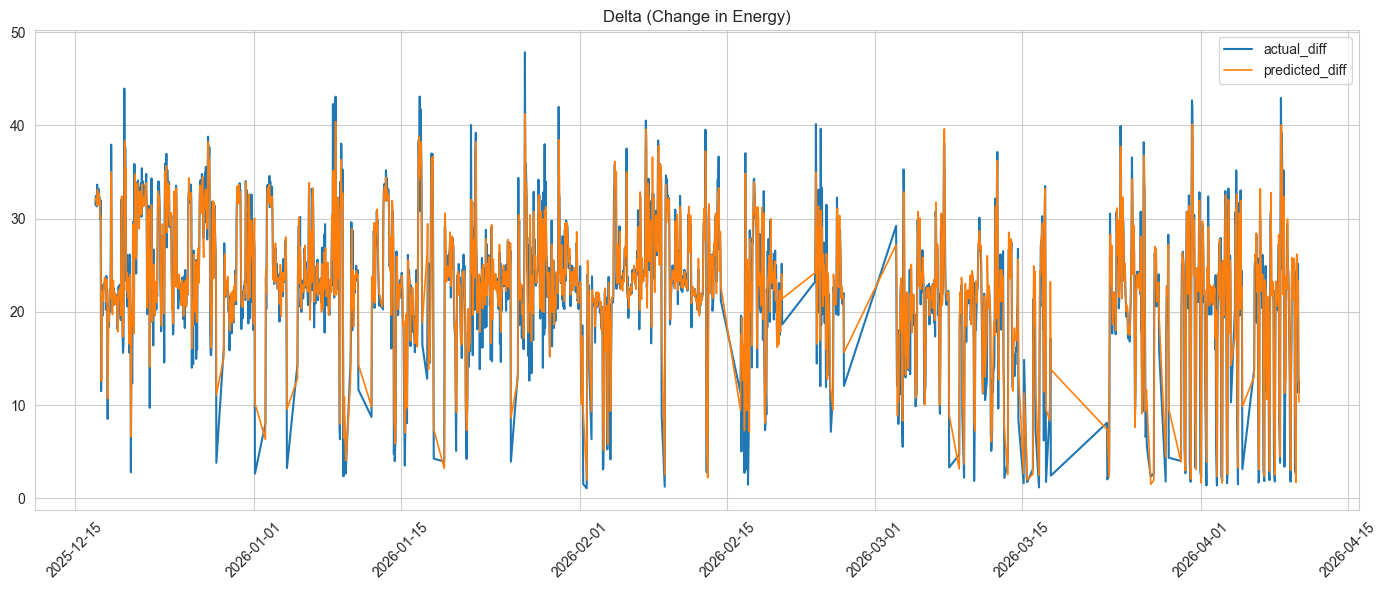

In [79]:
# predicted delta
pred_diff = pred['total_kwh'] - X_test['total_kwh_lag_1']

fig, ax = plt.subplots(figsize=(14, 6))

x_axis = test_df.loc[X_test.index, 'rtc_timestamp']

ax.plot(x_axis, y_test['target_diff'], label='actual_diff', linewidth=1.5)
ax.plot(x_axis, pred_diff, label='predicted_diff', linewidth=1.2)

ax.set_title('Delta (Change in Energy)')
ax.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [80]:
print(y_test_actual.head())

8076    295826.689859
8077    295859.095072
8078    295890.923333
8079    295922.230909
8080    295955.873913
Name: total_kwh, dtype: float64


In [81]:
print(pred.head())

          total_kwh
8076  295827.233654
8077  295858.697889
8078  295891.333316
8079  295922.325435
8080  295954.793348


## Anomaly Detection
Anomalies are identified using two signals:

- large forecast residuals
- unsupervised anomaly scoring with Isolation Forest

In [85]:
TARGET_COLS_FOR_ANOMALY = ['total_kwh']
results = test_df[['rtc_timestamp', 'meter_id'] + TARGET_COLS_FOR_ANOMALY].copy()
results = results.sort_values(['rtc_timestamp'])
for col in TARGET_COLS_FOR_ANOMALY:
    results[f'pred_{col}'] = pred[col]
    # Residual = actual − predicted
    # Positive → underprediction
    # Negative → overprediction
    results[f'resid_{col}'] = results[col] - results[f'pred_{col}'] 
    resid_std = results[f'resid_{col}'].std() if results[f'resid_{col}'].std() > 0 else 1.0
    results[f'z_{col}'] = results[f'resid_{col}'] / resid_std  # Standardize across different scales, Makes features comparable

residual_cols = [f'resid_{c}' for c in TARGET_COLS_FOR_ANOMALY]
# unsupervised anomaly detection algorithm based on the idea that anomalies are easier to isolate than normal points. Detects anomalies by isolating rare patterns. 3% expected anomalies
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)  
# Fit + Predict
# -1 → anomaly
# 1 → normal
results['iso_flag'] = iso.fit_predict(results[residual_cols])
# Higher score → normal
# Lower → more anomalous
results['iso_score'] = iso.decision_function(results[residual_cols])

# Detects extreme deviations
results['residual_rule_flag'] = (
    results[[f'z_{c}' for c in ['total_kwh']]].abs().max(axis=1) > 3
).astype(int)

# Combines ML + rule
results['anomaly_flag'] = ((results['iso_flag'] == -1) | (results['residual_rule_flag'] == 1)).astype(int)
results['anomaly_severity'] = (
    results[[f'z_{c}' for c in ['total_kwh']]].abs().max(axis=1)
).round(3)

anomalies = results[results['anomaly_flag'] == 1].sort_values('anomaly_severity', ascending=False)
anomalies[['rtc_timestamp', 'meter_id', 'total_kwh', 'pred_total_kwh', 'anomaly_severity']].head(15)

,rtc_timestamp,meter_id,total_kwh,pred_total_kwh,anomaly_severity
9350,2026-02-16 23:00:00,FUTU0000000004000002,326715.920000,326731.995250,6.174
9916,2026-03-31 23:00:00,FUTU0000000004000002,341616.480000,341630.946166,5.556
8721,2026-01-17 11:00:00,FUTU0000000004000002,311811.068125,311824.628082,5.208
9345,2026-02-16 18:00:00,FUTU0000000004000002,326652.692424,326665.881268,5.066
9441,2026-02-23 22:00:00,FUTU0000000004000002,329703.890140,329716.173679,4.718
9440,2026-02-23 21:00:00,FUTU0000000004000002,329685.318052,329673.654837,4.480
9763,2026-03-17 18:00:00,FUTU0000000004000002,338300.440000,338311.808946,4.367
8723,2026-01-17 14:00:00,FUTU0000000004000002,311883.992394,311872.650956,4.356
8950,2026-01-28 16:00:00,FUTU0000000004000002,317134.879273,317145.552283,4.099
8684,2026-01-15 12:00:00,FUTU0000000004000002,310898.097538,310908.429931,3.969


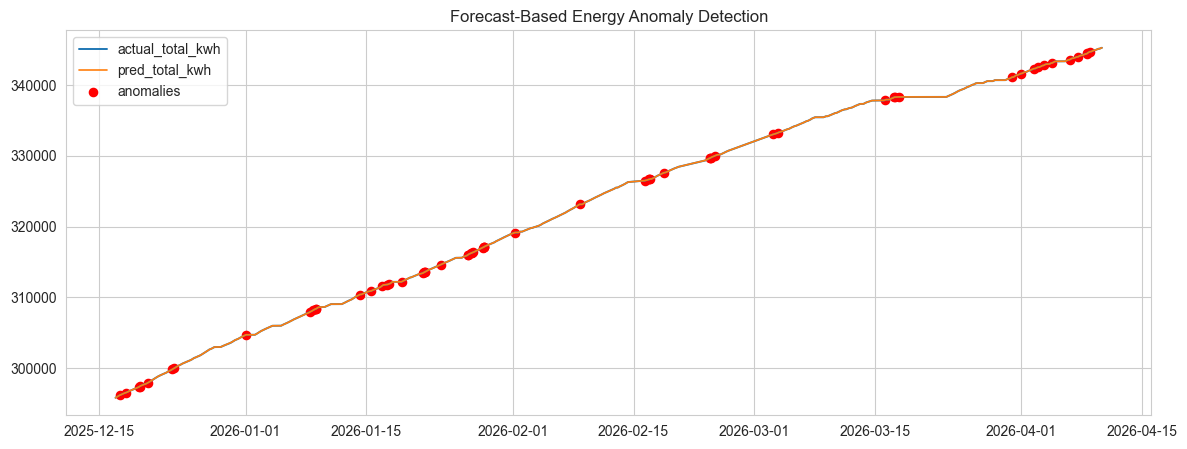

In [83]:
plt.figure(figsize=(14, 5))
plt.plot(results['rtc_timestamp'], results['total_kwh'], label='actual_total_kwh', linewidth=1.4)
plt.plot(results['rtc_timestamp'], results['pred_total_kwh'], label='pred_total_kwh', linewidth=1.2)
plt.scatter(
    anomalies['rtc_timestamp'],
    anomalies['total_kwh'],
    color='red',
    s=35,
    label='anomalies'
)
plt.title('Forecast-Based Energy Anomaly Detection')
plt.legend()
plt.show()

## Business Summary Payload

In [92]:
def build_summary_payload(metrics_df: pd.DataFrame, anomalies: pd.DataFrame) -> Dict:
    top_anoms = anomalies[[
        'rtc_timestamp', 'total_kwh', 'pred_total_kwh', 'anomaly_severity'
    ]].copy()

    top_anoms['rtc_timestamp'] = top_anoms['rtc_timestamp'].astype(str)

    return {
        'forecast_metrics': metrics_df.round(4).to_dict(orient='records'),
        'anomaly_count': int(anomalies.shape[0]),
        'top_anomalies': top_anoms.to_dict(orient='records'),
    }


summary_payload = build_summary_payload(metrics_df, anomalies)
summary_payload

{'forecast_metrics': [{'target': 'total_kwh',
   'MAE': 1.7912,
   'RMSE': 2.6177,
   'MAPE_pct': 0.0006}],
 'anomaly_count': 61,
 'top_anomalies': [{'rtc_timestamp': '2026-02-16 23:00:00',
   'total_kwh': 326715.92,
   'pred_total_kwh': 326731.9952502673,
   'anomaly_severity': 6.174},
  {'rtc_timestamp': '2026-03-31 23:00:00',
   'total_kwh': 341616.48,
   'pred_total_kwh': 341630.946165758,
   'anomaly_severity': 5.556},
  {'rtc_timestamp': '2026-01-17 11:00:00',
   'total_kwh': 311811.068125,
   'pred_total_kwh': 311824.6280823446,
   'anomaly_severity': 5.208},
  {'rtc_timestamp': '2026-02-16 18:00:00',
   'total_kwh': 326652.6924242424,
   'pred_total_kwh': 326665.881267528,
   'anomaly_severity': 5.066},
  {'rtc_timestamp': '2026-02-23 22:00:00',
   'total_kwh': 329703.890140056,
   'pred_total_kwh': 329716.1736793165,
   'anomaly_severity': 4.718},
  {'rtc_timestamp': '2026-02-23 21:00:00',
   'total_kwh': 329685.31805225654,
   'pred_total_kwh': 329673.6548373642,
   'anomaly_

## Gemini Summary

In [93]:
def build_gemini_prompt(payload: Dict) -> str:
    return f'''
You are an energy analytics assistant.

Create a concise business summary from this pipeline output.
The response must include:
1. forecast quality summary
2. main anomaly patterns
3. likely operational causes
5. a prioritized action list for facilities and energy teams

Pipeline output:
{json.dumps(payload, indent=2)}
'''

def gemini_summary(payload: Dict, model_name: str = 'models/gemini-2.5-flash') -> str:
    api_key = "GEMINI_API_KEY"
    if not api_key:
        return 'GEMINI_API_KEY not set. Skipping LLM summary.'

    try:
        from google import genai
        client = genai.Client(api_key="GEMINI_API_KEY")
        response = client.models.generate_content(model=model_name, contents=build_gemini_prompt(payload))
        return response.text
    except Exception as exc:
        return f'Gemini summary failed: {exc}'


llm_summary = gemini_summary(summary_payload)
print(llm_summary)

Here's a concise business summary of the pipeline output:

**Business Summary: Energy Consumption Analysis**

1.  **Forecast Quality Summary:** The energy consumption forecast demonstrates exceptionally high accuracy, with a Mean Absolute Percentage Error (MAPE) of just **0.0006%** and an average absolute deviation (MAE) of **1.79 kWh**. This indicates the model is highly reliable in predicting total kWh.

2.  **Main Anomaly Patterns:** A total of **61 anomalies** were detected. The most severe anomalies primarily show actual consumption being slightly **lower than predicted** (over-forecasting), while a greater number of less severe anomalies indicate consumption was slightly **higher than predicted** (under-forecasting). These deviations are very minor in absolute terms (typically less than 20 kWh on a baseline of 300-340 MWh). Anomalies occur across various times of day (late night/early morning and daytime peaks) and days of the week, suggesting subtle, distributed shifts rather th

## Final Pipeline Function

Use this function with your actual historical meter records.

In [ ]:
def run_energy_pipeline(input_df: pd.DataFrame) -> Dict:
    # Data cleaning and feature engineering
    staged = add_time_features(input_df)
    staged = add_time_signals(input_df)
    staged = add_lag_features(staged, ['total_kwh'])
    staged['target_diff'] = staged['total_kwh'] - staged['total_kwh_lag_1']
    staged = staged[feature_df['target_diff'].abs() > 1]
    staged = add_rolling_features(staged, ['total_kwh'])
    staged = staged.dropna().reset_index(drop=True)
    
    # Split the data 
    split_idx = int(len(staged) * 0.8)
    train_df = staged.iloc[:split_idx].copy()
    test_df = staged.iloc[split_idx:].copy()

    excluded = {
        'rtc_timestamp', '_id', 'meter_id', 'UID', 'timestamp', 'total_kwh', 'ratio_1', 'trend_6', 'hour_of_day', 'day_of_week', 'total_kwh_roll_mean_3', 'total_kwh_roll_mean_6', 'total_kwh_roll_mean_24'
    }
    feature_cols = [c for c in staged.columns if c not in excluded.union(TARGET_COLS)]

    X_train = train_df[feature_cols]
    y_train = train_df[TARGET_COLS]
    X_test = test_df[feature_cols]
    y_test = test_df[TARGET_COLS]
    
    # Model Training
    numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    numeric_features

    model = Pipeline(
        steps=[
            ('preprocessor', ColumnTransformer(
                transformers=[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_features)],
                remainder='drop'
            )),
            ('model', XGBRegressor(
                n_estimators=800,
                max_depth=8,
                learning_rate=0.03,
                subsample=0.9,
                colsample_bytree=0.9
            ))
        ]
    )

    model.fit(X_train, y_train)
    delta_pred = forecast_model.predict(X_test)
    pred = X_test['total_kwh_lag_1'].values + delta_pred
    pred = pd.DataFrame(pred, columns=['total_kwh'], index=X_test.index)
    y_test_actual = test_df['total_kwh'].loc[X_test.index]
    
    # Model evalution
    metrics = regression_metrics(y_test_actual.to_frame(), pred)

    # Anomal Detection
    results = test_df[['timestamp', 'meter_id'] + TARGET_COLS].copy()
    for col in TARGET_COLS:
        results[f'pred_{col}'] = pred[col]
        results[f'resid_{col}'] = results[col] - results[f'pred_{col}']
        resid_std = results[f'resid_{col}'].std() if results[f'resid_{col}'].std() > 0 else 1.0
        results[f'z_{col}'] = results[f'resid_{col}'] / resid_std

    iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
    residual_cols = [f'resid_{c}' for c in TARGET_COLS]
    results['iso_flag'] = iso.fit_predict(results[residual_cols])
    results['iso_score'] = iso.decision_function(results[residual_cols])
    results['residual_rule_flag'] = (
        results[[f'z_{c}' for c in ['total_kwh']]].abs().max(axis=1) > 3
    ).astype(int)
    results['anomaly_flag'] = ((results['iso_flag'] == -1) | (results['residual_rule_flag'] == 1)).astype(int)
    results['anomaly_severity'] = results[[f'z_{c}' for c in ['total_kwh']]].abs().max(axis=1)

    anomalies = results[results['anomaly_flag'] == 1].sort_values('anomaly_severity', ascending=False)
    
    # LLM Summarization
    payload = build_summary_payload(metrics, anomalies)
    llm_text = gemini_summary(payload)

    return {
        'model': model,
        'metrics': metrics,
        'predictions': pred,
        'results': results,
        'anomalies': anomalies,
        'summary_payload': payload,
        'llm_summary': llm_text
    }


pipeline_output = run_energy_pipeline(df)
pipeline_output['metrics']

In [ ]:
print('Anomalies detected:', len(pipeline_output['anomalies']))
print('Optimization summary:', pipeline_output['optimization_summary'])
print('\nGemini summary:\n')
print(pipeline_output['llm_summary'])